# Crop-profile geographical analysis

This notebook builds the dissertation's crop-profile geography extension. It uses UKCEH Land Cover plus: Crops 2022 to create a 10 km crop-composition grid, clusters grid cells into agricultural crop-profile zones, and joins existing model-disagreement outputs to those zones.

UKCEH is treated as a secondary crop-map product / benchmark layer, not ground truth. The point of this notebook is to explain where Sentinel-1 SAR added value varies by agricultural context.

In [39]:
# Mount Google Drive when running in Colab. Safe to skip outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as exc:
    IN_COLAB = False
    print('Not running in Colab, or Drive mount skipped:', exc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports and configuration

If running in Colab and geospatial packages are missing, uncomment the install cell below. In many Colab sessions, `geopandas`, `shapely`, `pyogrio` and `folium` are already available or can be installed quickly.

In [40]:
# Optional Colab install. Uncomment if imports fail.
# !pip install geopandas pyogrio shapely folium mapclassify scikit-learn matplotlib pandas numpy

In [41]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
    from shapely.geometry import box
except Exception as exc:
    raise ImportError('This notebook requires geopandas and shapely. In Colab, run: pip install geopandas pyogrio shapely') from exc

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    import folium
    FOLIUM_AVAILABLE = True
except Exception:
    FOLIUM_AVAILABLE = False

warnings.filterwarnings('ignore', category=UserWarning)

# --- 配置参数 ---
FINAL_K = 4  # 你可以在这里修改为 4
GRID_SIZE_M = 10_000
MIN_SELECTED_CROP_AREA_HA = 500
K_RANGE = range(2, 9)
RANDOM_SEED = 42

# --- 路径配置 ---
if IN_COLAB:
    PROJECT_DIR = Path('/content/drive/MyDrive/Dissertation')
else:
    PROJECT_DIR = Path.cwd()

RUN_DIR = PROJECT_DIR / '6_crop_profile_geography'

# 根据 K 值动态设定输出根目录，实现分开保存
k_suffix = f'k{FINAL_K}' if FINAL_K is not None else 'k_auto'
OUTPUT_ROOT = RUN_DIR / 'outputs' / k_suffix

TABLE_DIR = OUTPUT_ROOT / 'tables'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
MAP_DIR = OUTPUT_ROOT / 'maps'
GEO_DIR = OUTPUT_ROOT / 'geo'
LOG_DIR = OUTPUT_ROOT / 'logs'
DOC_DIR = OUTPUT_ROOT / 'docs'

for folder in [TABLE_DIR, FIGURE_DIR, MAP_DIR, GEO_DIR, LOG_DIR, DOC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# 数据路径
UKCEH_LAYER = 'crop_map_2022'
UKCEH_GPKG = PROJECT_DIR / 'ukceh_east_anglia' / 'lccm-2022_6395063' / 'lccm-2022_6395063.gpkg'
if not UKCEH_GPKG.exists():
    UKCEH_GPKG = PROJECT_DIR / 'data' / 'ukceh_east_anglia' / 'lccm-2022_6395063' / 'lccm-2022_6395063.gpkg'

BOUNDARY_PATH = PROJECT_DIR / 'data' / 'geo_data' / 'selected_areas' / 'East_Anglia_Boundary.geojson'
MODEL_POINTS_GPKG = PROJECT_DIR / '3_spatial_error_analysis' / 'outputs' / 'matched_test_predictions_spatial_error.gpkg'
MODEL_POINTS_CSV = PROJECT_DIR / '3_spatial_error_analysis' / 'outputs' / 'tables' / 'matched_test_predictions_spatial_error.csv'
MODEL_UKCEH_CSV = PROJECT_DIR / '4_ukceh_benchmark_comparison' / 'outputs' / 'tables' / 'matched_test_predictions_with_ukceh_labels.csv'

print(f'当前项目目录: {PROJECT_DIR}')
print(f'当前 K 值设定: {k_suffix}')
print(f'结果将保存至: {OUTPUT_ROOT}')

当前项目目录: /content/drive/MyDrive/Dissertation
当前 K 值设定: k4
结果将保存至: /content/drive/MyDrive/Dissertation/6_crop_profile_geography/outputs/k4


## 2. Helper functions

In [42]:
ANALYSIS_CLASSES = [
    'Winter wheat',
    'Winter barley',
    'Spring barley',
    'Beet (sugar beet / fodder beet)',
    'Maize',
    'Oilseed rape',
    'Potatoes',
    'Pulses / field beans and peas',
]

UKCEH_CODE_TO_CLASS = {
    'ww': 'Winter wheat',
    'wb': 'Winter barley',
    'sb': 'Spring barley',
    'be': 'Beet (sugar beet / fodder beet)',
    'ma': 'Maize',
    'or': 'Oilseed rape',
    'po': 'Potatoes',
    'fs': 'Pulses / field beans and peas',
    'fw': 'Pulses / field beans and peas',
    'pe': 'Pulses / field beans and peas',
}

UKCEH_NAME_TO_CLASS = {
    'Winter wheat': 'Winter wheat',
    'Winter barley': 'Winter barley',
    'Spring barley': 'Spring barley',
    'Beet (sugar beet / fodder beet)': 'Beet (sugar beet / fodder beet)',
    'Maize': 'Maize',
    'Oilseed rape': 'Oilseed rape',
    'Potatoes': 'Potatoes',
    'Spring field beans': 'Pulses / field beans and peas',
    'Winter field beans': 'Pulses / field beans and peas',
    'Peas': 'Pulses / field beans and peas',
}

def find_ukceh_gpkg():
    if UKCEH_GPKG is not None:
        p = Path(UKCEH_GPKG)
        if p.exists():
            return p
        raise FileNotFoundError(f'UKCEH_GPKG was set but does not exist: {p}')
    for p in CANDIDATE_UKCEH_GPKG:
        if p.exists():
            return p
    raise FileNotFoundError(
        'Could not find UKCEH Land Cover plus: Crops 2022 GeoPackage. Set UKCEH_GPKG in the configuration cell. '
        'Expected file name: lccm-2022_6395063.gpkg, layer crop_map_2022.'
    )

def clean_col(name):
    return str(name).replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('-', '_').lower()

def make_grid(bounds, cell_size=10_000, crs='EPSG:27700'):
    minx, miny, maxx, maxy = bounds
    minx = np.floor(minx / cell_size) * cell_size
    miny = np.floor(miny / cell_size) * cell_size
    maxx = np.ceil(maxx / cell_size) * cell_size
    maxy = np.ceil(maxy / cell_size) * cell_size
    records = []
    gid = 0
    for x in np.arange(minx, maxx, cell_size):
        for y in np.arange(miny, maxy, cell_size):
            gid += 1
            records.append({'grid_id': f'g{gid:04d}', 'geometry': box(x, y, x + cell_size, y + cell_size)})
    return gpd.GeoDataFrame(records, crs=crs)

def describe_cluster(row, proportion_cols, top_n=3):
    values = row[proportion_cols].sort_values(ascending=False)
    top = values.head(top_n)
    parts = []
    for col, value in top.items():
        crop = col.replace('prop_', '').replace('_', ' ')
        parts.append(f'{crop} {value:.0%}')
    return '; '.join(parts)

def parse_bool_series(series):
    if series.dtype == bool:
        return series
    mapped = series.astype(str).str.strip().str.lower().map({
        'true': True,
        '1': True,
        'yes': True,
        'y': True,
        'false': False,
        '0': False,
        'no': False,
        'n': False,
        'nan': np.nan,
        'none': np.nan,
        '': np.nan,
    })
    return mapped

def save_static_map(gdf, column, path, title, cmap='viridis', legend=True):
    fig, ax = plt.subplots(figsize=(9, 9))
    gdf.plot(column=column, ax=ax, cmap=cmap, legend=legend, edgecolor='white', linewidth=0.2)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.close(fig)

def save_folium_choropleth(gdf, column, path, tooltip_cols, legend_name):
    if not FOLIUM_AVAILABLE:
        print('Folium not available; skipping', path)
        return
    web = gdf.to_crs(4326).copy()
    centroid = web.geometry.unary_union.centroid
    m = folium.Map(location=[centroid.y, centroid.x], zoom_start=8, tiles='cartodbpositron')
    folium.Choropleth(
        geo_data=web.to_json(),
        data=web.drop(columns='geometry'),
        columns=['grid_id', column],
        key_on='feature.properties.grid_id',
        fill_color='YlGnBu',
        fill_opacity=0.75,
        line_opacity=0.25,
        legend_name=legend_name,
    ).add_to(m)
    folium.GeoJson(
        web,
        style_function=lambda feature: {'fillOpacity': 0, 'color': '#333333', 'weight': 0.4},
        tooltip=folium.GeoJsonTooltip(fields=tooltip_cols, aliases=tooltip_cols, localize=True),
    ).add_to(m)
    m.save(path)
    print('Saved', path)

## 3. Load UKCEH crops and build the 10 km grid

In [43]:
ukceh_path = find_ukceh_gpkg()
print('Using UKCEH:', ukceh_path)

ukceh = gpd.read_file(ukceh_path, layer=UKCEH_LAYER)
if ukceh.crs is None:
    ukceh = ukceh.set_crs(27700)
ukceh = ukceh.to_crs(27700)

if 'crop_code' in ukceh.columns:
    ukceh['analysis_class'] = ukceh['crop_code'].astype(str).str.lower().map(UKCEH_CODE_TO_CLASS)
else:
    ukceh['analysis_class'] = np.nan
if ukceh['analysis_class'].isna().any() and 'crop_name' in ukceh.columns:
    by_name = ukceh['crop_name'].map(UKCEH_NAME_TO_CLASS)
    ukceh['analysis_class'] = ukceh['analysis_class'].fillna(by_name)

ukceh_main = ukceh[ukceh['analysis_class'].isin(ANALYSIS_CLASSES)].copy()
ukceh_main = ukceh_main[~ukceh_main.geometry.is_empty & ukceh_main.geometry.notna()].copy()

if BOUNDARY_PATH.exists():
    boundary = gpd.read_file(BOUNDARY_PATH).to_crs(27700)
    study_area = boundary.dissolve().reset_index(drop=True)
    ukceh_main = gpd.clip(ukceh_main, study_area)
else:
    study_area = gpd.GeoDataFrame({'name': ['UKCEH extent']}, geometry=[box(*ukceh_main.total_bounds)], crs=27700)

grid = make_grid(study_area.total_bounds, GRID_SIZE_M, crs='EPSG:27700')
grid = gpd.overlay(grid, study_area[['geometry']], how='intersection')
grid['grid_area_ha'] = grid.geometry.area / 10_000

print('UKCEH retained crop polygons:', len(ukceh_main))
print('Grid cells before crop-area filter:', len(grid))
display(ukceh_main['analysis_class'].value_counts().reindex(ANALYSIS_CLASSES))

Using UKCEH: /content/drive/MyDrive/Dissertation/ukceh_east_anglia/lccm-2022_6395063/lccm-2022_6395063.gpkg
UKCEH retained crop polygons: 67635
Grid cells before crop-area filter: 153


,count
analysis_class,
Winter wheat,30092
Winter barley,8996
Spring barley,7149
Beet (sugar beet / fodder beet),6058
Maize,3261
Oilseed rape,4590
Potatoes,2810
Pulses / field beans and peas,4679


## 4. Calculate crop area and proportions by grid cell

In [44]:
crop_parts = gpd.overlay(
    ukceh_main[['analysis_class', 'geometry']],
    grid[['grid_id', 'geometry']],
    how='intersection',
)
crop_parts['area_ha'] = crop_parts.geometry.area / 10_000

area_long = (
    crop_parts.groupby(['grid_id', 'analysis_class'], as_index=False)['area_ha']
    .sum()
    .sort_values(['grid_id', 'analysis_class'])
)
area_wide = area_long.pivot(index='grid_id', columns='analysis_class', values='area_ha').fillna(0)
area_wide = area_wide.reindex(columns=ANALYSIS_CLASSES, fill_value=0)
area_wide.columns = [f'area_{clean_col(c)}_ha' for c in area_wide.columns]
area_wide = area_wide.reset_index()

profile = grid.merge(area_wide, on='grid_id', how='left').fillna(0)
area_cols = [c for c in profile.columns if c.startswith('area_') and c.endswith('_ha') and c != 'grid_area_ha']
profile['selected_crop_area_ha'] = profile[area_cols].sum(axis=1)
profile['selected_crop_intensity'] = profile['selected_crop_area_ha'] / profile['grid_area_ha']

for area_col in area_cols:
    prop_col = 'prop_' + area_col.removeprefix('area_').removesuffix('_ha')
    profile[prop_col] = np.where(profile['selected_crop_area_ha'] > 0, profile[area_col] / profile['selected_crop_area_ha'], 0)

profile['retained_for_clustering'] = profile['selected_crop_area_ha'] >= MIN_SELECTED_CROP_AREA_HA
profile_retained = profile[profile['retained_for_clustering']].copy()

filter_summary = pd.DataFrame([
    {'metric': 'grid_cells_total', 'value': len(profile)},
    {'metric': 'grid_cells_retained', 'value': len(profile_retained)},
    {'metric': 'min_selected_crop_area_ha', 'value': MIN_SELECTED_CROP_AREA_HA},
    {'metric': 'retained_selected_crop_area_ha', 'value': profile_retained['selected_crop_area_ha'].sum()},
])

profile.drop(columns='geometry').to_csv(TABLE_DIR / 'crop_profile_grid_area_table.csv', index=False)
prop_cols = [c for c in profile.columns if c.startswith('prop_')]
profile[['grid_id', 'grid_area_ha', 'selected_crop_area_ha', 'selected_crop_intensity', 'retained_for_clustering', *prop_cols]].to_csv(
    TABLE_DIR / 'crop_profile_grid_proportion_table.csv', index=False
)
filter_summary.to_csv(TABLE_DIR / 'crop_profile_grid_filter_summary.csv', index=False)
profile.to_file(GEO_DIR / 'crop_profile_grid.gpkg', layer='crop_profile_grid', driver='GPKG')

display(filter_summary)
display(profile_retained[['grid_id', 'selected_crop_area_ha', 'selected_crop_intensity']].describe())

,metric,value
0,grid_cells_total,153.000000
1,grid_cells_retained,144.000000
2,min_selected_crop_area_ha,500.000000
3,retained_selected_crop_area_ha,646113.556656


,selected_crop_area_ha,selected_crop_intensity
count,144.000000,144.000000
mean,4486.899699,0.509743
std,1911.821066,0.151507
min,528.246084,0.089250
25%,2823.964713,0.404732
50%,5053.880493,0.529657
75%,5967.374788,0.630776
max,7909.444931,0.811046


## 5. Cluster crop-profile zones

In [45]:
prop_cols = [c for c in profile_retained.columns if c.startswith('prop_')]
X = profile_retained[prop_cols].to_numpy()

silhouette_rows = []
for k in K_RANGE:
    if len(profile_retained) <= k:
        continue
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_rows.append({'k': k, 'silhouette_score': score})

silhouette_df = pd.DataFrame(silhouette_rows)
if silhouette_df.empty:
    raise ValueError('Not enough retained grid cells for clustering. Lower MIN_SELECTED_CROP_AREA_HA or check UKCEH coverage.')

chosen_k = int(FINAL_K) if FINAL_K is not None else int(silhouette_df.sort_values('silhouette_score', ascending=False).iloc[0]['k'])
km_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_SEED, n_init=50)
profile_retained['cluster_id'] = km_final.fit_predict(X) + 1

centroids = pd.DataFrame(km_final.cluster_centers_, columns=prop_cols)
centroids.insert(0, 'cluster_id', range(1, chosen_k + 1))
centroids['zone_profile_summary'] = centroids.apply(lambda row: describe_cluster(row, prop_cols), axis=1)

cluster_counts = profile_retained.groupby('cluster_id', as_index=False).agg(
    grid_cells=('grid_id', 'count'),
    selected_crop_area_ha=('selected_crop_area_ha', 'sum'),
    mean_selected_crop_intensity=('selected_crop_intensity', 'mean'),
)
centroids = centroids.merge(cluster_counts, on='cluster_id', how='left')

profile_clustered = profile.merge(profile_retained[['grid_id', 'cluster_id']], on='grid_id', how='left')
profile_clustered['cluster_label'] = profile_clustered['cluster_id'].map(
    centroids.set_index('cluster_id')['zone_profile_summary']
)

silhouette_df.to_csv(TABLE_DIR / 'crop_profile_cluster_silhouette_scores.csv', index=False)
centroids.to_csv(TABLE_DIR / 'crop_profile_cluster_centroids.csv', index=False)
profile_clustered.to_file(GEO_DIR / 'crop_profile_grid_with_clusters.gpkg', layer='crop_profile_grid_with_clusters', driver='GPKG')

display(silhouette_df)
display(centroids)

,k,silhouette_score
0,2,0.412183
1,3,0.311635
2,4,0.260925
3,5,0.236413
4,6,0.238296
5,7,0.194368
6,8,0.193100


,cluster_id,prop_winter_wheat,prop_winter_barley,prop_spring_barley,prop_beet_sugar_beet___fodder_beet,prop_maize,prop_oilseed_rape,prop_potatoes,prop_pulses___field_beans_and_peas,zone_profile_summary,grid_cells,selected_crop_area_ha,mean_selected_crop_intensity
0,1,0.359234,0.172454,0.116390,0.112858,0.050801,0.078468,0.051037,0.058758,winter wheat 36%; winter barley 17%; spring ba...,43,176982.010858,0.463444
1,2,0.185818,0.255767,0.157691,0.146102,0.064309,0.046704,0.090275,0.053334,winter barley 26%; winter wheat 19%; spring ba...,20,59741.374225,0.349251
2,3,0.502726,0.080732,0.063329,0.116385,0.062365,0.039432,0.072069,0.062962,winter wheat 50%; beet sugar beet fodder bee...,28,141801.552119,0.567480
3,4,0.541618,0.120528,0.091426,0.043736,0.013911,0.094357,0.009561,0.084862,winter wheat 54%; winter barley 12%; oilseed r...,53,267588.619453,0.577368


## 6. Static maps for dissertation figures

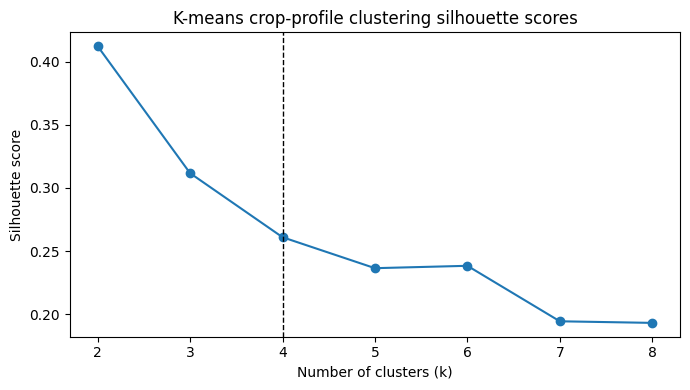

Saved static maps and silhouette figure to /content/drive/MyDrive/Dissertation/6_crop_profile_geography/outputs/k4/figures


In [46]:
save_static_map(
    profile_clustered,
    'selected_crop_intensity',
    FIGURE_DIR / 'selected_crop_intensity_map.png',
    'Selected eight-class crop intensity by 10 km grid cell',
    cmap='YlGn',
)

cluster_plot = profile_clustered.dropna(subset=['cluster_id']).copy()
cluster_plot['cluster_id'] = cluster_plot['cluster_id'].astype(int)
save_static_map(
    cluster_plot,
    'cluster_id',
    FIGURE_DIR / 'crop_profile_cluster_map.png',
    f'Crop-profile agricultural zones, k={chosen_k}',
    cmap='tab10',
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(silhouette_df['k'], silhouette_df['silhouette_score'], marker='o')
ax.axvline(chosen_k, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('K-means crop-profile clustering silhouette scores')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'crop_profile_silhouette_scores.png', dpi=300)
plt.show()

print('Saved static maps and silhouette figure to', FIGURE_DIR)

## 7. Join model disagreement points to crop-profile zones

In [47]:
if MODEL_POINTS_GPKG.exists():
    model_points = gpd.read_file(MODEL_POINTS_GPKG).to_crs(27700)
elif MODEL_POINTS_CSV.exists():
    model_csv = pd.read_csv(MODEL_POINTS_CSV)
    x_col = next((c for c in ['x', 'easting', 'Easting'] if c in model_csv.columns), None)
    y_col = next((c for c in ['y', 'northing', 'Northing'] if c in model_csv.columns), None)
    if x_col is None or y_col is None:
        raise FileNotFoundError('Model points GPKG not found and CSV has no x/y columns.')
    model_points = gpd.GeoDataFrame(model_csv, geometry=gpd.points_from_xy(model_csv[x_col], model_csv[y_col]), crs=27700)
else:
    raise FileNotFoundError('No model disagreement point file found.')

zones = profile_clustered.dropna(subset=['cluster_id']).copy()
zones['cluster_id'] = zones['cluster_id'].astype(int)
joined = gpd.sjoin(
    model_points,
    zones[['grid_id', 'cluster_id', 'cluster_label', 'geometry']],
    how='left',
    predicate='within',
)

if 'correct_s2' in joined.columns and 'correct_s1s2' in joined.columns:
    joined['correct_s2_bool'] = parse_bool_series(joined['correct_s2'])
    joined['correct_s1s2_bool'] = parse_bool_series(joined['correct_s1s2'])
    joined['s2_disagreement'] = joined['correct_s2_bool'].map(lambda v: np.nan if pd.isna(v) else not bool(v))
    joined['s1s2_disagreement'] = joined['correct_s1s2_bool'].map(lambda v: np.nan if pd.isna(v) else not bool(v))
elif 'status' in joined.columns:
    raise ValueError('Could not find correct_s2/correct_s1s2 columns. Inspect joined.columns and adapt this cell.')
else:
    raise ValueError('Could not find model correctness columns. Inspect joined.columns and adapt this cell.')

zone_disagreement = joined.dropna(subset=['cluster_id']).groupby(['cluster_id', 'cluster_label'], as_index=False).agg(
    n_test_samples=('s2_disagreement', 'size'),
    s2_disagreement_rate=('s2_disagreement', 'mean'),
    s1s2_disagreement_rate=('s1s2_disagreement', 'mean'),
)
zone_disagreement['sar_disagreement_reduction'] = zone_disagreement['s2_disagreement_rate'] - zone_disagreement['s1s2_disagreement_rate']

if MODEL_UKCEH_CSV.exists() and 'sample_uid' in joined.columns:
    ukceh_pred = pd.read_csv(MODEL_UKCEH_CSV)
    if {'sample_uid', 'crome_ukceh_agree'}.issubset(ukceh_pred.columns):
        joined = joined.merge(ukceh_pred[['sample_uid', 'crome_ukceh_agree']], on='sample_uid', how='left')
        joined['crome_ukceh_agree_bool'] = parse_bool_series(joined['crome_ukceh_agree'])
        joined['crome_ukceh_disagreement'] = joined['crome_ukceh_agree_bool'].map(lambda v: np.nan if pd.isna(v) else not bool(v))
        zone_ref = joined.dropna(subset=['cluster_id']).groupby(['cluster_id', 'cluster_label'], as_index=False).agg(
            n_ukceh_labelled_samples=('crome_ukceh_disagreement', 'count'),
            crome_ukceh_disagreement_rate=('crome_ukceh_disagreement', 'mean'),
        )
    else:
        zone_ref = pd.DataFrame(columns=['cluster_id', 'cluster_label', 'n_ukceh_labelled_samples', 'crome_ukceh_disagreement_rate'])
else:
    zone_ref = pd.DataFrame(columns=['cluster_id', 'cluster_label', 'n_ukceh_labelled_samples', 'crome_ukceh_disagreement_rate'])

zone_disagreement.to_csv(TABLE_DIR / 'zone_level_model_disagreement.csv', index=False)
zone_ref.to_csv(TABLE_DIR / 'zone_level_crome_ukceh_disagreement.csv', index=False)
joined.to_file(GEO_DIR / 'model_points_with_crop_profile_zone.gpkg', layer='model_points_with_crop_profile_zone', driver='GPKG')

display(zone_disagreement.sort_values('sar_disagreement_reduction', ascending=False))
display(zone_ref)

,cluster_id,cluster_label,n_test_samples,s2_disagreement_rate,s1s2_disagreement_rate,sar_disagreement_reduction
2,3.0,winter wheat 50%; beet sugar beet fodder bee...,359,0.292479,0.208914,0.083565
0,1.0,winter wheat 36%; winter barley 17%; spring ba...,528,0.304924,0.223485,0.081439
1,2.0,winter barley 26%; winter wheat 19%; spring ba...,255,0.274510,0.203922,0.070588
3,4.0,winter wheat 54%; winter barley 12%; oilseed r...,575,0.259130,0.198261,0.060870


,cluster_id,cluster_label,n_ukceh_labelled_samples,crome_ukceh_disagreement_rate


## 8. Zone-level SAR reduction figure and map

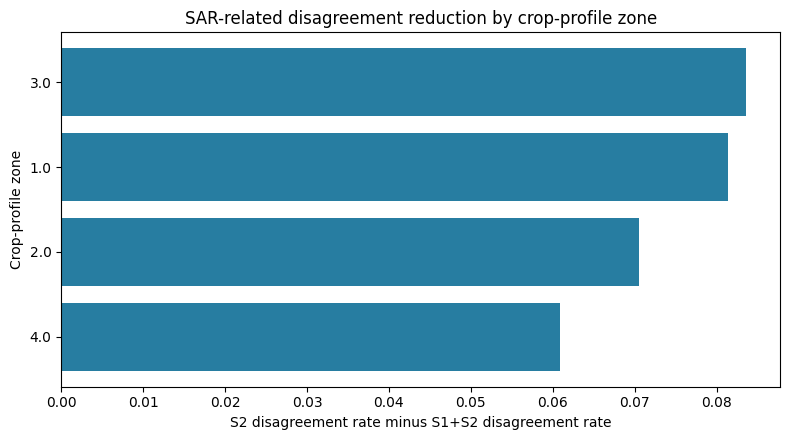

In [48]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_zone = zone_disagreement.sort_values('sar_disagreement_reduction', ascending=True).copy()
ax.barh(plot_zone['cluster_id'].astype(str), plot_zone['sar_disagreement_reduction'], color='#277da1')
ax.set_xlabel('S2 disagreement rate minus S1+S2 disagreement rate')
ax.set_ylabel('Crop-profile zone')
ax.set_title('SAR-related disagreement reduction by crop-profile zone')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'zone_level_sar_reduction_bar.png', dpi=300)
plt.show()

zone_map = zones.merge(zone_disagreement[['cluster_id', 'sar_disagreement_reduction', 'n_test_samples']], on='cluster_id', how='left')
if zone_map['sar_disagreement_reduction'].notna().any():
    save_static_map(
        zone_map,
        'sar_disagreement_reduction',
        FIGURE_DIR / 'zone_level_sar_reduction_map.png',
        'SAR-related disagreement reduction by crop-profile zone',
        cmap='Blues',
    )

## 9. Optional HTML maps

In [49]:
if FOLIUM_AVAILABLE:
    html_base = profile_clustered.copy()
    tooltip_cols = ['grid_id', 'selected_crop_area_ha', 'selected_crop_intensity', 'cluster_id', 'cluster_label']
    tooltip_cols = [c for c in tooltip_cols if c in html_base.columns]
    save_folium_choropleth(
        html_base,
        'selected_crop_intensity',
        MAP_DIR / 'selected_crop_intensity_map.html',
        tooltip_cols,
        'Selected eight-class crop intensity',
    )
    save_folium_choropleth(
        html_base.dropna(subset=['cluster_id']).assign(cluster_id=lambda d: d['cluster_id'].astype(int)),
        'cluster_id',
        MAP_DIR / 'crop_profile_cluster_map.html',
        tooltip_cols,
        'Crop-profile cluster',
    )
    if 'sar_disagreement_reduction' in zone_map.columns and zone_map['sar_disagreement_reduction'].notna().any():
        save_folium_choropleth(
            zone_map,
            'sar_disagreement_reduction',
            MAP_DIR / 'zone_level_sar_reduction_map.html',
            [c for c in ['grid_id', 'cluster_id', 'cluster_label', 'sar_disagreement_reduction', 'n_test_samples'] if c in zone_map.columns],
            'SAR disagreement reduction',
        )
else:
    print('Folium is not installed; skipping HTML maps.')

/tmp/ipykernel_1176/3881311415.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = web.geometry.unary_union.centroid


Saved /content/drive/MyDrive/Dissertation/6_crop_profile_geography/outputs/k4/maps/selected_crop_intensity_map.html


/tmp/ipykernel_1176/3881311415.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = web.geometry.unary_union.centroid


Saved /content/drive/MyDrive/Dissertation/6_crop_profile_geography/outputs/k4/maps/crop_profile_cluster_map.html


/tmp/ipykernel_1176/3881311415.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = web.geometry.unary_union.centroid


Saved /content/drive/MyDrive/Dissertation/6_crop_profile_geography/outputs/k4/maps/zone_level_sar_reduction_map.html


## 10. Run notes and manifest

In [50]:
manifest = {
    'run_datetime': datetime.now().isoformat(timespec='seconds'),
    'ukceh_gpkg': str(ukceh_path),
    'ukceh_layer': UKCEH_LAYER,
    'boundary_path': str(BOUNDARY_PATH),
    'model_points_gpkg': str(MODEL_POINTS_GPKG),
    'grid_size_m': GRID_SIZE_M,
    'min_selected_crop_area_ha': MIN_SELECTED_CROP_AREA_HA,
    'retained_grid_cells': int(len(profile_retained)),
    'chosen_k': int(chosen_k),
    'analysis_classes': ANALYSIS_CLASSES,
    'interpretation_note': 'UKCEH used as a secondary crop-map product for crop-profile aggregation, not ground truth.',
}
(LOG_DIR / 'crop_profile_run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

top_zone = zone_disagreement.sort_values('sar_disagreement_reduction', ascending=False).iloc[0] if len(zone_disagreement) else None
notes = f'''# Crop-profile geography notes

Date run: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Purpose

This analysis uses UKCEH Land Cover plus: Crops 2022 to create 10 km crop-profile grid cells, cluster them into agricultural crop-composition zones, and examine whether Sentinel-1 SAR disagreement reduction varies by zone.

## Setup

- UKCEH source: `{ukceh_path}`
- Grid size: {GRID_SIZE_M:,} m
- Minimum selected-crop area threshold: {MIN_SELECTED_CROP_AREA_HA:,} ha
- Retained grid cells for clustering: {len(profile_retained):,}
- Chosen number of clusters: {chosen_k}
- Reference framing: UKCEH is used as a secondary crop-map product, not direct ground truth.

## Key outputs

- Crop-profile area/proportion tables: `outputs/tables/crop_profile_grid_area_table.csv` and `outputs/tables/crop_profile_grid_proportion_table.csv`
- Cluster centroids: `outputs/tables/crop_profile_cluster_centroids.csv`
- Zone-level model disagreement: `outputs/tables/zone_level_model_disagreement.csv`
- Static dissertation figures: `outputs/figures/selected_crop_intensity_map.png`, `outputs/figures/crop_profile_cluster_map.png`, `outputs/figures/zone_level_sar_reduction_bar.png`
- Optional HTML maps: `outputs/maps/`

## Initial interpretation

Use the cluster centroid table to name agricultural zones cautiously. The zone-level disagreement table should be used to test whether SAR disagreement reduction is larger in zones associated with potatoes, beet, maize or pulses than in cereal-dominant zones. Small-sample zones should be treated as descriptive only.
'''

if top_zone is not None:
    notes += f"\nThe largest observed SAR disagreement reduction is in cluster {int(top_zone['cluster_id'])}, with reduction {top_zone['sar_disagreement_reduction']:.3f} across {int(top_zone['n_test_samples'])} matched test samples.\n"

(DOC_DIR / 'crop_profile_geography_notes.md').write_text(notes, encoding='utf-8')
print(notes)
print('Saved manifest and notes.')

# Crop-profile geography notes

Date run: 2026-07-07 16:12

## Purpose

This analysis uses UKCEH Land Cover plus: Crops 2022 to create 10 km crop-profile grid cells, cluster them into agricultural crop-composition zones, and examine whether Sentinel-1 SAR disagreement reduction varies by zone.

## Setup

- UKCEH source: `/content/drive/MyDrive/Dissertation/ukceh_east_anglia/lccm-2022_6395063/lccm-2022_6395063.gpkg`
- Grid size: 10,000 m
- Minimum selected-crop area threshold: 500 ha
- Retained grid cells for clustering: 144
- Chosen number of clusters: 4
- Reference framing: UKCEH is used as a secondary crop-map product, not direct ground truth.

## Key outputs

- Crop-profile area/proportion tables: `outputs/tables/crop_profile_grid_area_table.csv` and `outputs/tables/crop_profile_grid_proportion_table.csv`
- Cluster centroids: `outputs/tables/crop_profile_cluster_centroids.csv`
- Zone-level model disagreement: `outputs/tables/zone_level_model_disagreement.csv`
- Static dissertation f

In [51]:
# Final output checklist
expected = [
    TABLE_DIR / 'crop_profile_grid_area_table.csv',
    TABLE_DIR / 'crop_profile_grid_proportion_table.csv',
    TABLE_DIR / 'crop_profile_grid_filter_summary.csv',
    TABLE_DIR / 'crop_profile_cluster_silhouette_scores.csv',
    TABLE_DIR / 'crop_profile_cluster_centroids.csv',
    TABLE_DIR / 'zone_level_model_disagreement.csv',
    TABLE_DIR / 'zone_level_crome_ukceh_disagreement.csv',
    GEO_DIR / 'crop_profile_grid.gpkg',
    GEO_DIR / 'crop_profile_grid_with_clusters.gpkg',
    GEO_DIR / 'model_points_with_crop_profile_zone.gpkg',
    FIGURE_DIR / 'selected_crop_intensity_map.png',
    FIGURE_DIR / 'crop_profile_cluster_map.png',
    FIGURE_DIR / 'crop_profile_silhouette_scores.png',
    FIGURE_DIR / 'zone_level_sar_reduction_bar.png',
    LOG_DIR / 'crop_profile_run_manifest.json',
    DOC_DIR / 'crop_profile_geography_notes.md',
]
check = pd.DataFrame({
    'path': [str(p.relative_to(RUN_DIR)) if p.exists() else str(p) for p in expected],
    'exists': [p.exists() for p in expected],
    'size_bytes': [p.stat().st_size if p.exists() else 0 for p in expected],
})
display(check)

,path,exists,size_bytes
0,outputs/k4/tables/crop_profile_grid_area_table...,True,54774
1,outputs/k4/tables/crop_profile_grid_proportion...,True,33071
2,outputs/k4/tables/crop_profile_grid_filter_sum...,True,143
3,outputs/k4/tables/crop_profile_cluster_silhoue...,True,170
4,outputs/k4/tables/crop_profile_cluster_centroi...,True,1305
5,outputs/k4/tables/zone_level_model_disagreemen...,True,614
6,outputs/k4/tables/zone_level_crome_ukceh_disag...,True,80
7,outputs/k4/geo/crop_profile_grid.gpkg,True,512000
8,outputs/k4/geo/crop_profile_grid_with_clusters...,True,532480
9,outputs/k4/geo/model_points_with_crop_profile_...,True,716800
